# Notebook 01: Data Loading, Exploration and Preprocessing

We have built this notebook to prepare Beijing Multi-Site Air Quality data for every
modelling stage that follows. Data arrives as twelve separate CSV files, one per
monitoring station, and all of them share same schema.

Output of this notebook is a single cleaned file, `beijing_aqi_clean.parquet`. Every
later notebook loads that file instead of reading raw CSVs again.

**Dataset:** Beijing Multi-Site Air Quality, UCI Machine Learning Repository, ID 501.
420,768 hourly readings, 12 stations, March 2013 to February 2017.

We are not going to touch every variable in detail here, but we will cover structure,
missing values, outliers, distributions, station differences and temporal patterns
before any preprocessing is applied.

**Stages in this notebook:**

1. Load and combine twelve station files
2. Structure, data types and duplicates
3. Missing values
4. Outliers
5. Distributions of pollutants
6. Station comparison
7. Temporal patterns
8. Correlation between variables
9. Feature engineering
10. Target derivation
11. Preprocessing pipeline
12. Train and test split, sampling helper
13. Save cleaned data


## 0. Setup

Environment is created with `uv`. Commands below are run once in terminal.

```bash
uv venv .venv
. .venv/bin/activate
uv pip install pandas numpy matplotlib seaborn scikit-learn pyarrow
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load and Combine Twelve Station Files

Each file holds one station and columns are identical across all of them. We read all
twelve and concatenate them into one frame, keeping `station` column so site identity
is never lost.

Loader checks local `data/` folder first. If files are not present there, it falls back
to a public mirror so notebook still runs.

In [2]:
STATIONS = ["Aotizhongxin","Changping","Dingling","Dongsi","Guanyuan","Gucheng",
            "Huairou","Nongzhanguan","Shunyi","Tiantan","Wanliu","Wanshouxigong"]
# BASE = "https://raw.githubusercontent.com/KM-drago/Beijing-Multi-Site-Air-Quality-Data/main/"

def load_data(data_dir="data"):
    frames = []
    for s in STATIONS:
        fn = f"PRSA_Data_{s}_20130301-20170228.csv"
        path = os.path.join(data_dir, fn)
        frames.append(pd.read_csv(path if os.path.exists(path) else BASE + fn))
    return pd.concat(frames, ignore_index=True)

df = load_data()
print("Combined shape:", df.shape)
df.head()

Combined shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 2. Structure, Data Types and Duplicates

First thing to establish is what kind of data sits in each column. Pollutants and
weather values are numeric. Wind direction and station name are text.

In [3]:
print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])
print("Stations:", df["station"].nunique())
df.info()

Rows: 420,768 | Columns: 18
Stations: 12
<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


### Summary statistics

`describe()` gives spread of every numeric column. Two things are clearly visible in
output below. Pollutant maximums sit far above their medians, and that already signals
heavy skew. Rain is zero for most of the record.

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.50,10122.12,1.00,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.66,1.18,2013.00,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.52,3.45,1.00,4.00,7.0,10.00,12.0
day,420768.0,15.73,8.80,1.00,8.00,16.0,23.00,31.0
hour,420768.0,11.50,6.92,0.00,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.79,80.82,2.00,20.00,55.0,111.00,999.0
PM10,414319.0,104.60,91.77,2.00,36.00,82.0,145.00,999.0
SO2,411747.0,15.83,21.65,0.29,3.00,7.0,20.00,500.0
NO2,408652.0,50.64,35.13,1.03,23.00,43.0,71.00,290.0
CO,400067.0,1230.77,1160.18,100.00,500.00,900.0,1500.00,10000.0


### Time coverage

Four separate columns hold time (`year`, `month`, `day`, `hour`). We check that record
is continuous and that every station carries same number of rows.

In [5]:
dt = pd.to_datetime(df[["year","month","day","hour"]])
print("From:", dt.min(), " to:", dt.max())
print("Rows per station:", len(df) // df["station"].nunique())
print("Expected hourly slots:", int((dt.max() - dt.min()).total_seconds() // 3600) + 1)

From: 2013-03-01 00:00:00  to: 2017-02-28 23:00:00
Rows per station: 35064
Expected hourly slots: 35064


### Duplicate check

Duplicated rows would inflate a station's weight during training. We check on the
combination that must be unique, i.e station plus timestamp.

In [6]:
key = ["station","year","month","day","hour"]
dupes_full = int(df.duplicated().sum())
dupes_key  = int(df.duplicated(subset=key).sum())

print("Fully duplicated rows      :", dupes_full)
print("Duplicated station + time  :", dupes_key)
if dupes_full == 0 and dupes_key == 0:
    print()
    print("No duplicates. Each station has exactly one reading per hour.")

Fully duplicated rows      : 0
Duplicated station + time  : 0

No duplicates. Each station has exactly one reading per hour.


## 3. Missing Values

Gaps in this dataset are real sensor downtime, not synthetic missingness. It must be
noted that pollutant channels carry far more gaps than weather channels.

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing": missing, "Percent": pct})

,Missing,Percent
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
TEMP,398,0.09
PRES,393,0.09


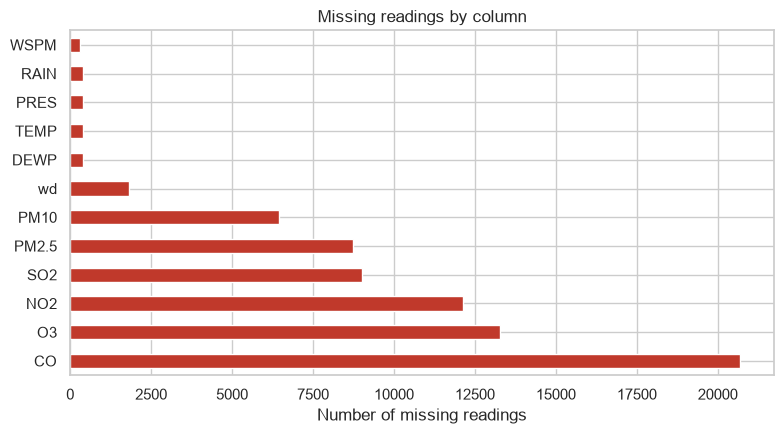

In [8]:
ax = missing.plot(kind="barh", figsize=(8,4.5), color="#c0392b")
ax.set_title("Missing readings by column")
ax.set_xlabel("Number of missing readings")
plt.tight_layout()
plt.show()

CO carries most gaps at 20,701 readings, and O3 follows at 13,277. Weather columns
lose fewer than 500 readings each. Reason for this difference is that pollutant
analysers need regular calibration and maintenance, while weather instruments don't.

Even worst affected column is missing under 5 percent of its readings, so imputation
stays a reasonable option here. Dropping every incomplete row would throw away roughly
a quarter of dataset for no good reason.

## 4. Outliers

Pollutant maximums in summary table are extreme. PM2.5 reaches close to 1000 µg/m³,
which is more than ten times its own median. We check how many readings fall outside
usual interquartile range.

In [9]:
POLLUTANTS = ["PM2.5","PM10","SO2","NO2","CO","O3"]

rows = []
for col in POLLUTANTS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = int((df[col] > upper).sum())
    rows.append({"Pollutant": col,
                 "Median": round(df[col].median(), 1),
                 "IQR upper fence": round(upper, 1),
                 "Maximum": round(df[col].max(), 1),
                 "Above fence": n_out,
                 "Percent": round(n_out / df[col].notna().sum() * 100, 2)})

pd.DataFrame(rows)

,Pollutant,Median,IQR upper fence,Maximum,Above fence,Percent
0,PM2.5,55.0,247.5,999.0,19142,4.65
1,PM10,82.0,308.5,999.0,14658,3.54
2,SO2,7.0,45.5,500.0,35566,8.64
3,NO2,43.0,143.0,290.0,7021,1.72
4,CO,900.0,3000.0,10000.0,28054,7.01
5,O3,45.0,188.5,1071.0,16599,4.07


### These outliers are kept, and reason matters

Standard instinct is to trim or cap values above fence. We are not doing that here.

Extreme readings in this dataset are Beijing's severe smog episodes. They are genuine
measurements of exactly conditions a warning system exists to catch. Removing them
would clean data and destroy problem at same time.

A real life example is like this, a hospital wants to know when air becomes dangerous
for asthma patients. If we delete every reading above 250 µg/m³ because it looks
unusual, model never learns what dangerous air looks like. It only learns average days.

So outliers stay in dataset. What we do instead is choose methods that tolerate them.
Median is used for imputation instead of mean, and macro-F1 is reported instead of
plain accuracy in later notebooks.

## 5. Distributions of Pollutants

Histograms below show shape of each pollutant. All six lean heavily to right.

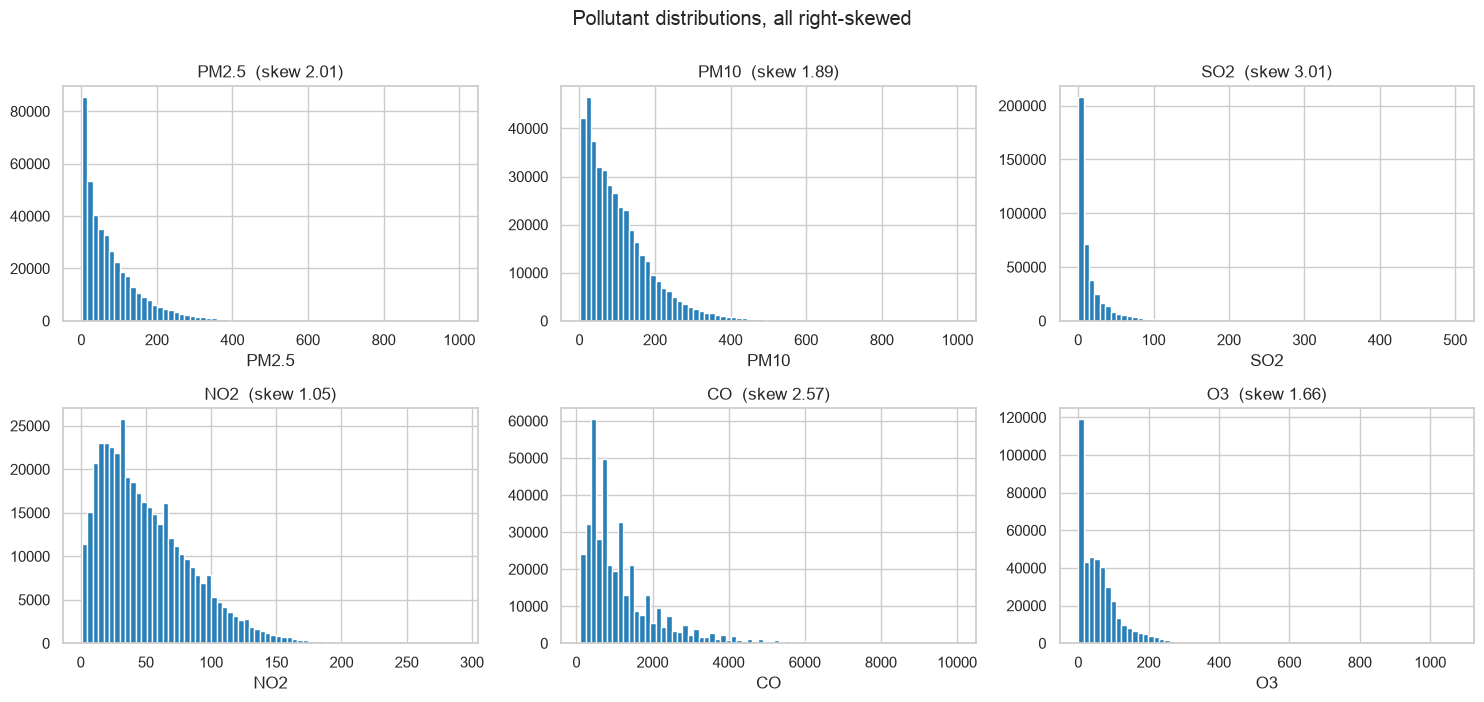

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), POLLUTANTS):
    ax.hist(df[col].dropna(), bins=70, color="#2980b9")
    ax.set_title(f"{col}  (skew {df[col].skew():.2f})")
    ax.set_xlabel(col)
fig.suptitle("Pollutant distributions, all right-skewed", y=1.00)
plt.tight_layout()
plt.show()

In [11]:
skews = df[POLLUTANTS + ["TEMP","PRES","DEWP","WSPM"]].skew().sort_values(ascending=False)
print("Skewness, highest first:")
print(skews.round(2).to_string())

Skewness, highest first:
SO2      3.01
CO       2.57
PM2.5    2.01
PM10     1.89
O3       1.66
WSPM     1.63
NO2      1.05
PRES     0.11
TEMP    -0.10
DEWP    -0.19


Every pollutant carries positive skew. SO2 and CO are worst affected. Weather columns
sit close to symmetric, and temperature is very nearly so.

This shape decides two later choices. Median imputation is used for numeric columns,
and RMSE in regression notebook gets read alongside MAE because a handful of smog hours
otherwise dominate squared error.

### Log scale makes shape clearer
Same PM2.5 values, plotted on log axis. Distribution turns close to symmetric, which
clears the idea that skew comes from a long tail and not from two separate groups.

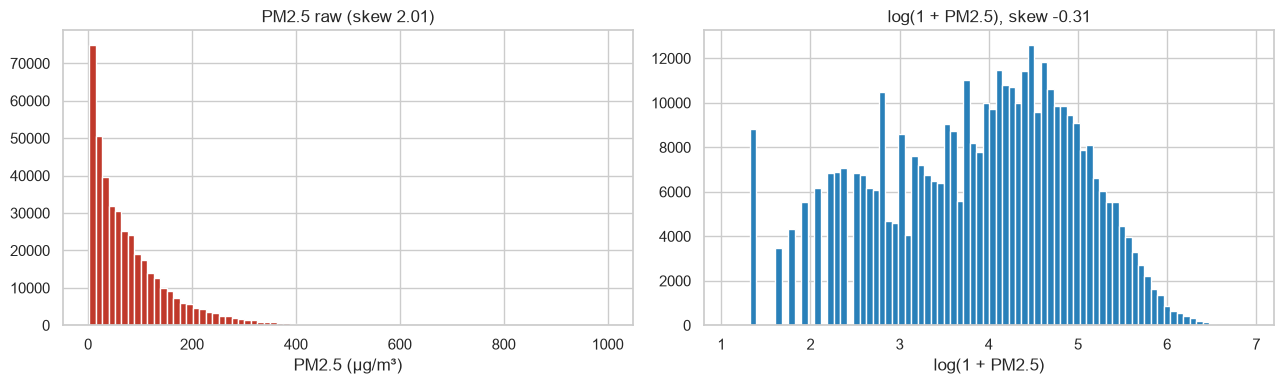

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["PM2.5"].dropna(), bins=80, color="#c0392b")
axes[0].set_title(f"PM2.5 raw (skew {df['PM2.5'].skew():.2f})")
axes[0].set_xlabel("PM2.5 (µg/m³)")

logged = np.log1p(df["PM2.5"].dropna())
axes[1].hist(logged, bins=80, color="#2980b9")
axes[1].set_title(f"log(1 + PM2.5), skew {logged.skew():.2f}")
axes[1].set_xlabel("log(1 + PM2.5)")
plt.tight_layout()
plt.show()

## 6. Station Comparison

Twelve stations sit in different parts of city. Boxplots below compare PM2.5 across all
of them. Plot uses a 60,000 row sample, because rendering full 420,768 points is slow
and adds nothing to picture.

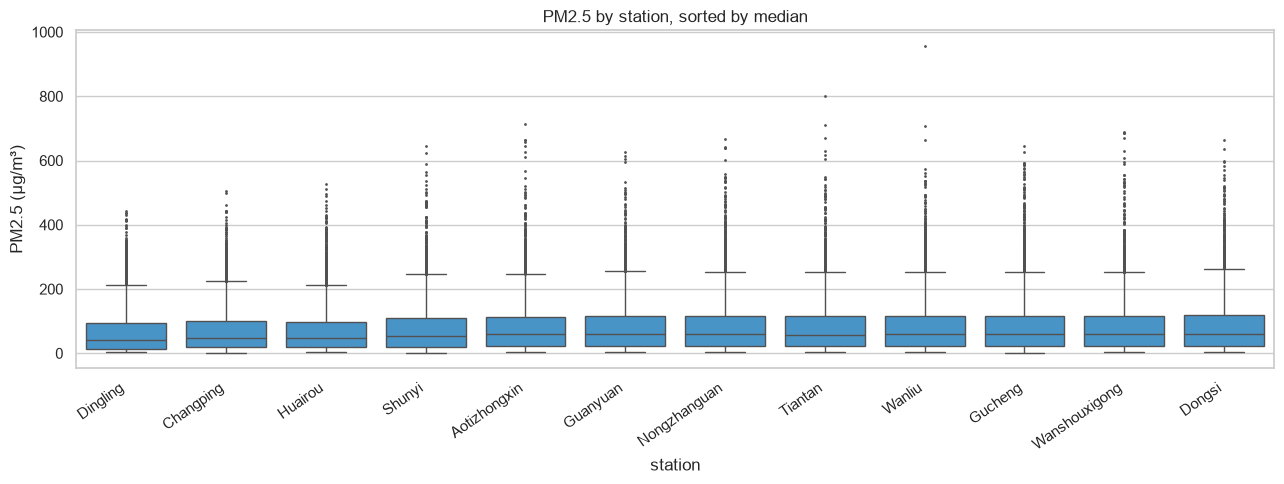

In [13]:
sample_plot = df.sample(n=60_000, random_state=RANDOM_STATE)

order = df.groupby("station")["PM2.5"].median().sort_values().index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=sample_plot, x="station", y="PM2.5", order=order,
            color="#3498db", fliersize=1, ax=ax)
ax.set_title("PM2.5 by station, sorted by median")
ax.set_ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [28]:
station_means = df.groupby("station")[POLLUTANTS].mean().round(1)
station_means["n_readings"] = df.groupby("station").size()
station_means.sort_values("PM2.5")

,PM2.5,PM10,SO2,NO2,CO,O3,n_readings
station,,,,,,,
Dingling,66.0,83.7,11.7,27.6,904.9,68.5,35064
Huairou,69.6,91.5,12.1,32.5,1022.6,59.8,35064
Changping,71.1,94.7,15.0,44.2,1152.3,57.9,35064
Shunyi,79.5,98.7,13.6,43.9,1187.1,55.2,35064
Tiantan,82.2,106.4,14.4,53.2,1298.3,56.0,35064
Aotizhongxin,82.8,110.1,17.4,59.3,1262.9,56.4,35064
Guanyuan,82.9,109.0,17.6,57.9,1271.3,55.8,35064
Wanliu,83.4,110.5,18.4,65.3,1319.4,48.9,35064
Gucheng,83.9,118.9,15.4,55.9,1324.0,57.7,35064


Dingling, Huairou and Changping carry lowest PM2.5 medians. All three of them sit in
northern suburban districts. Dongsi, Wanshouxigong and Nongzhanguan sit inside urban
core and carry highest values.

NO2 gap is worth mentioning here. Urban stations run close to 56 µg/m³ while suburban
ones run close to 35 µg/m³. NO2 comes mostly from vehicles, so this gap points to
traffic density rather than to anything about measurement.

Notebook 05 takes this further and clusters stations formally.

## 7. Temporal Patterns

Three cycles matter in this data. Pollution changes by hour of day, by month of year,
and slowly across four years of record.

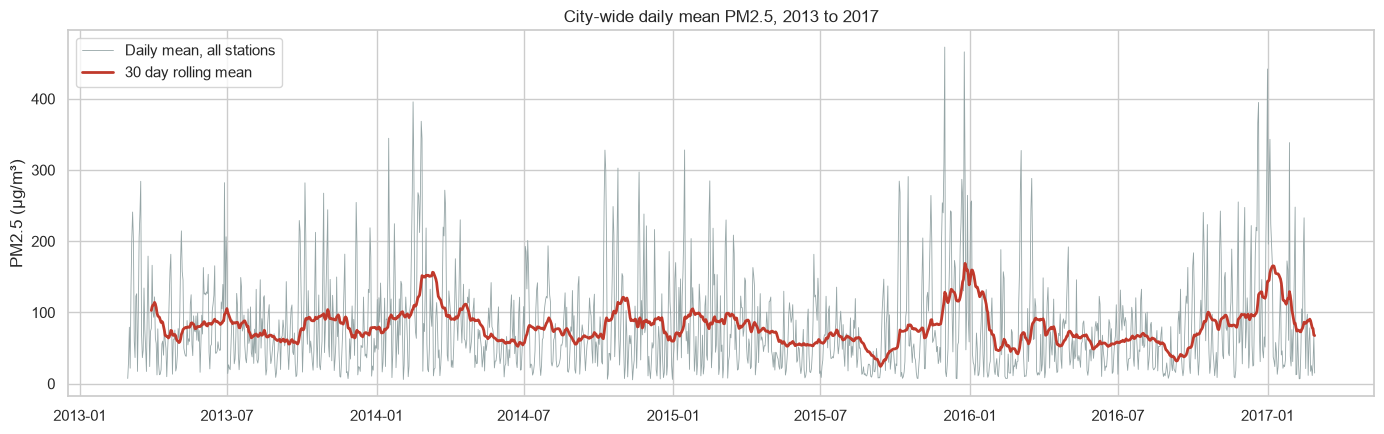

In [14]:
tmp = df.copy()
tmp["datetime"] = pd.to_datetime(tmp[["year","month","day","hour"]])
city_daily = tmp.groupby(tmp["datetime"].dt.date)["PM2.5"].mean()
city_daily.index = pd.to_datetime(city_daily.index)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(city_daily.index, city_daily.values, lw=0.6, color="#95a5a6",
        label="Daily mean, all stations")
ax.plot(city_daily.index, city_daily.rolling(30).mean(), lw=2, color="#c0392b",
        label="30 day rolling mean")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("City-wide daily mean PM2.5, 2013 to 2017")
ax.legend()
plt.tight_layout()
plt.show()

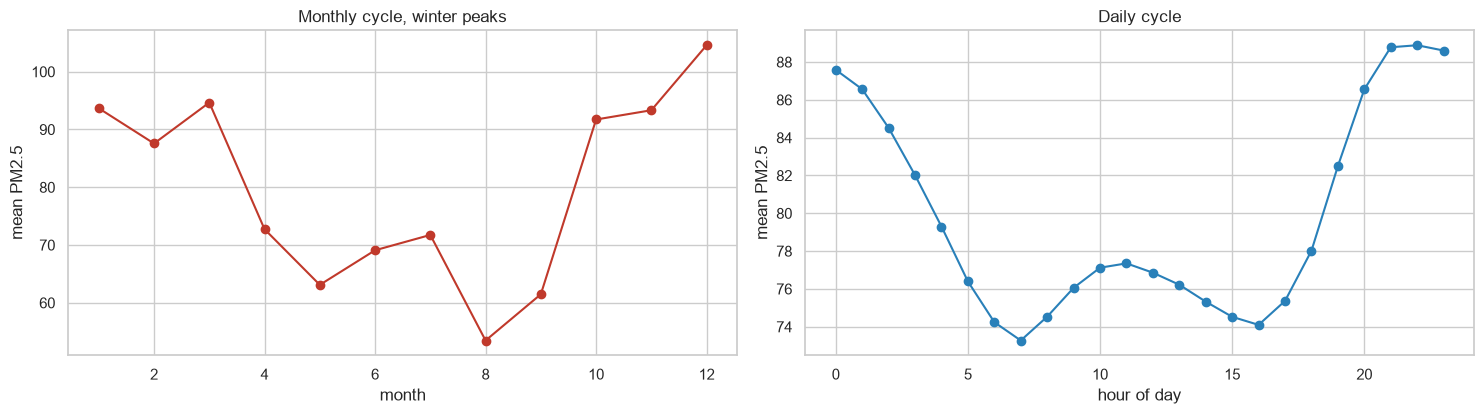

Highest month: 12 (104.6)
Lowest month : 8 (53.5)
Peak hour    : 22 (88.9)
Quietest hour: 7 (73.3)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))

by_month = tmp.groupby("month")["PM2.5"].mean()
axes[0].plot(by_month.index, by_month.values, "o-", color="#c0392b")
axes[0].set_xlabel("month"); axes[0].set_ylabel("mean PM2.5")
axes[0].set_title("Monthly cycle, winter peaks")

by_hour = tmp.groupby("hour")["PM2.5"].mean()
axes[1].plot(by_hour.index, by_hour.values, "o-", color="#2980b9")
axes[1].set_xlabel("hour of day"); axes[1].set_ylabel("mean PM2.5")
axes[1].set_title("Daily cycle")
plt.tight_layout()
plt.show()

print("Highest month:", int(by_month.idxmax()), f"({by_month.max():.1f})")
print("Lowest month :", int(by_month.idxmin()), f"({by_month.min():.1f})")
print("Peak hour    :", int(by_hour.idxmax()), f"({by_hour.max():.1f})")
print("Quietest hour:", int(by_hour.idxmin()), f"({by_hour.min():.1f})")

Winter months run far above summer months. Coal heating starts in November and that
shows up clearly in monthly curve.

Daily curve is flatter than monthly one, but it still carries a shape. Values dip in
late afternoon when wind and mixing are strongest, then climb again overnight.

Both cycles have to reach models in a usable form, and section 9 handles that.

## 8. Correlation Between Variables

Pollutants share their sources, so they move together. Heatmap below shows how strongly.

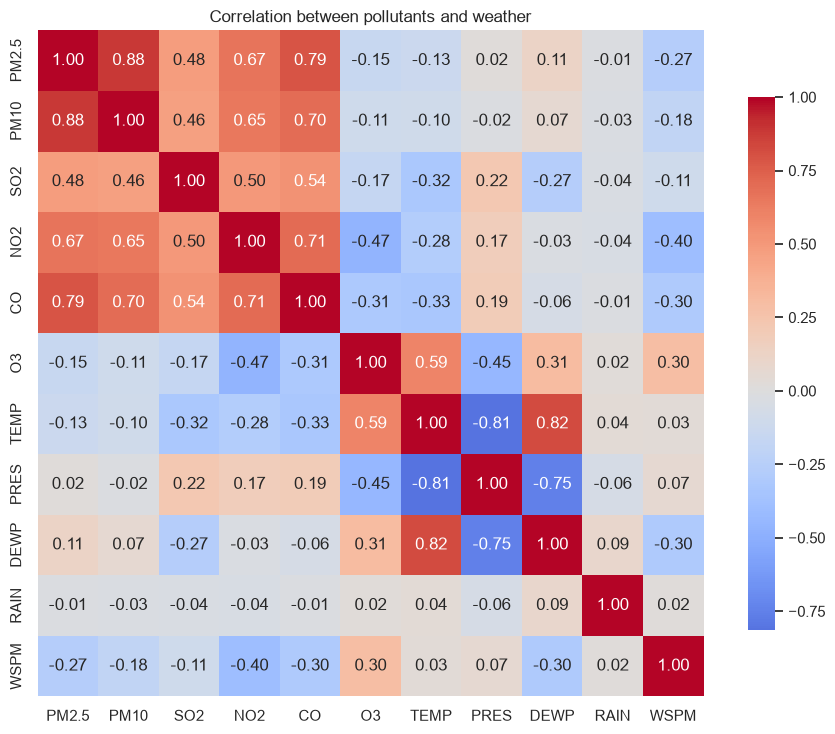

In [16]:
num_cols = POLLUTANTS + ["TEMP","PRES","DEWP","RAIN","WSPM"]
plt.figure(figsize=(9.5, 7.5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation between pollutants and weather")
plt.tight_layout()
plt.show()

PM2.5 and PM10 correlate very strongly, and that is expected because PM2.5 particles
are physically a subset of PM10. CO also tracks PM2.5 closely. Both come out of same
combustion sources.

Temperature and dew point correlate strongly with each other. Dew point can't exceed
temperature, so this relation is physical and not a data problem.

It must be noted that this pattern is what justifies Ridge, Lasso and ElasticNet in
Notebook 04. Correlated predictors make ordinary least squares unstable, and Notebook 04
measures that formally with variance inflation factors.

### Pairwise view
Pairplot uses a 3,000 row sample and colours points by season. Scatter panels show
relations that single correlation numbers flatten out.

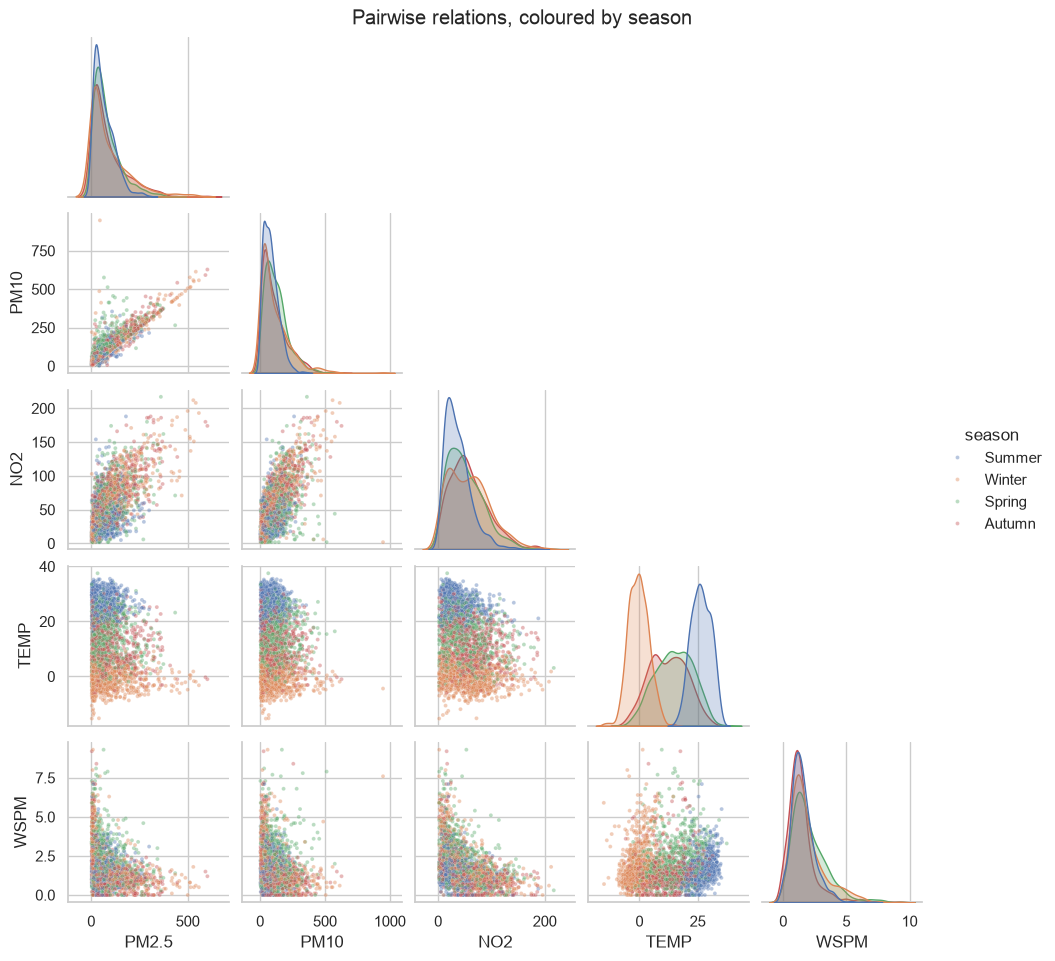

In [17]:
pair_cols = ["PM2.5","PM10","NO2","TEMP","WSPM"]
season_map = {12:"Winter",1:"Winter",2:"Winter", 3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer", 9:"Autumn",10:"Autumn",11:"Autumn"}
pair_sample = (df.assign(season=df["month"].map(season_map))
                 .dropna(subset=pair_cols)
                 .sample(n=3_000, random_state=RANDOM_STATE))

g = sns.pairplot(pair_sample[pair_cols + ["season"]], hue="season",
                 corner=True, plot_kws={"s": 8, "alpha": 0.4}, height=1.9)
g.figure.suptitle("Pairwise relations, coloured by season", y=1.01)
plt.show()

Winter points sit high on PM2.5 and PM10 axes and cluster at low temperature. Summer
points sit low on particulates. Wind speed panel shows a clear funnel, i.e high PM2.5
appears only when wind is weak.

That funnel is worth keeping in mind. Wind clears pollution, so Beijing's smog is partly
a ventilation problem and not only an emissions problem.

## 9. Feature Engineering

Three changes are applied here.

**Datetime column.** Four time columns get combined into one timestamp. Time series work
in Notebook 06 needs it, and every plot above needed it too.

**Row index dropped.** Column `No` is a per station counter and carries no information.

**Cyclical time encoding.** Hour 23 and hour 00 sit next to each other in reality, but as
plain numbers they look 23 apart. Sine and cosine pair fixes that for both hour and
month. A readable `season` column is added alongside for grouping.

In [18]:
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.drop(columns=["No"])

df["season"] = df["month"].map(season_map)

df["hour_sin"]  = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]  = np.cos(2*np.pi*df["hour"]/24)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

print("Shape after feature engineering:", df.shape)
df[["datetime","season","hour_sin","hour_cos","month_sin","month_cos"]].head()

Shape after feature engineering: (420768, 23)


,datetime,season,hour_sin,hour_cos,month_sin,month_cos
0,2013-03-01 00:00:00,Spring,0.000000,1.000000,1.0,6.123234e-17
1,2013-03-01 01:00:00,Spring,0.258819,0.965926,1.0,6.123234e-17
2,2013-03-01 02:00:00,Spring,0.500000,0.866025,1.0,6.123234e-17
3,2013-03-01 03:00:00,Spring,0.707107,0.707107,1.0,6.123234e-17
4,2013-03-01 04:00:00,Spring,0.866025,0.500000,1.0,6.123234e-17


### Why cyclical encoding is needed
Plot below shows hour values before and after transformation. On sine and cosine circle,
hour 23 sits directly next to hour 00, which is correct. On plain scale they sit at
opposite ends.

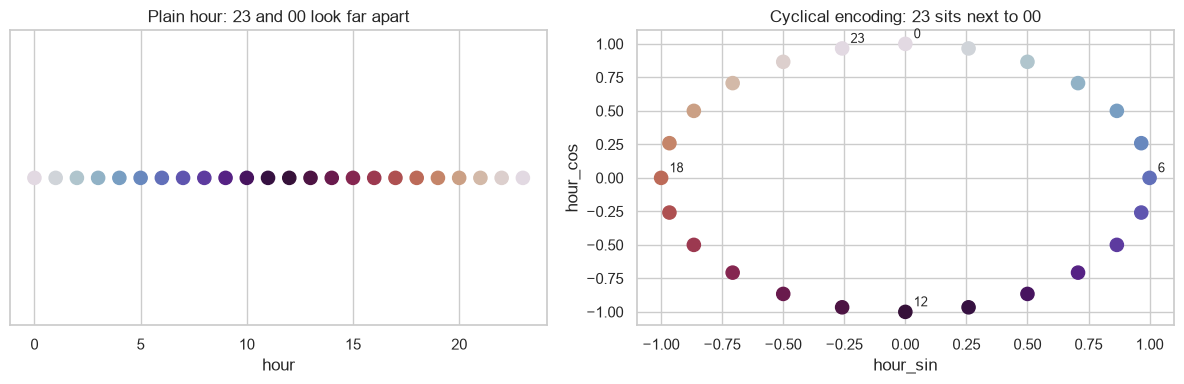

In [19]:
hours = np.arange(24)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(hours, np.zeros_like(hours), c=hours, cmap="twilight", s=90)
axes[0].set_title("Plain hour: 23 and 00 look far apart")
axes[0].set_xlabel("hour"); axes[0].set_yticks([])

axes[1].scatter(np.sin(2*np.pi*hours/24), np.cos(2*np.pi*hours/24),
                c=hours, cmap="twilight", s=90)
for h in [0, 6, 12, 18, 23]:
    axes[1].annotate(str(h), (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
                     xytext=(6, 4), textcoords="offset points", fontsize=9)
axes[1].set_title("Cyclical encoding: 23 sits next to 00")
axes[1].set_xlabel("hour_sin"); axes[1].set_ylabel("hour_cos")
plt.tight_layout()
plt.show()

## 10. Target Derivation

One measurement produces three targets. That is what lets regression, multiclass
classification and binary classification run on identical inputs.

| Target | Type | Used by |
|---|---|---|
| `PM2.5` | continuous | Notebook 04 |
| `AQI_Category` | six classes | Notebook 02 |
| `Unhealthy` | binary | Notebook 03 |

`AQI_Category` uses US EPA breakpoints for PM2.5 concentration.

In [20]:
bins   = [-1, 12, 35.4, 55.4, 150.4, 250.4, np.inf]
labels = ["Good","Moderate","Unhealthy(Sensitive)",
          "Unhealthy","Very Unhealthy","Hazardous"]

df["AQI_Category"] = pd.cut(df["PM2.5"], bins=bins, labels=labels)

# NaN safe: rows without a PM2.5 reading must stay missing, not become 0
mask = df["PM2.5"].notna()
df["Unhealthy"] = pd.Series(pd.NA, index=df.index, dtype="Int64")
df.loc[mask, "Unhealthy"] = (df.loc[mask, "PM2.5"] > 55.4).astype("Int64")

print(df["AQI_Category"].value_counts().sort_index().to_string())
print()
print("Binary target:")
print(df["Unhealthy"].value_counts(dropna=False).to_string())

AQI_Category
Good                     62775
Moderate                 91096
Unhealthy(Sensitive)     53248
Unhealthy               142240
Very Unhealthy           44234
Hazardous                18436

Binary target:
Unhealthy
0       207119
1       204910
<NA>      8739


### A comparison trap in the binary target

Writing `(df["PM2.5"] > 55.4)` looks correct and is not. In pandas, `NaN > 55.4`
evaluates to `False`. All 8,739 rows without a PM2.5 reading would then get labelled
`0`, i.e "not unhealthy", and that invents 8,739 negative labels out of nothing.

Code above masks those rows so they stay `<NA>` and get dropped later. `pd.cut()`
already handles this correctly for `AQI_Category` and returns `NaN`, which is why only
binary target was exposed.

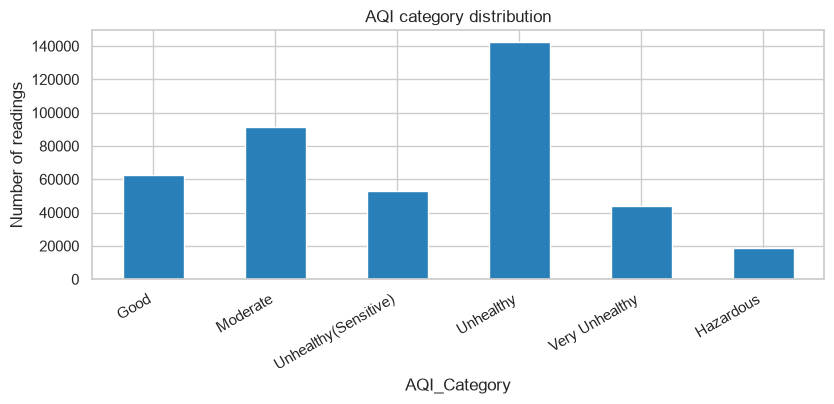

In [21]:
ax = df["AQI_Category"].value_counts().sort_index().plot(
        kind="bar", figsize=(8.5,4.2), color="#2980b9")
ax.set_title("AQI category distribution")
ax.set_ylabel("Number of readings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Two targets, two different balance profiles

Two outputs above look like they contradict each other. They don't, and difference
decides how each task gets measured.

`AQI_Category` is heavily imbalanced. Hazardous holds around 4.5 percent of readings
while Unhealthy holds around 34.5 percent, close to an eight fold gap.

`Unhealthy` is almost balanced at 50.3 and 49.7 percent.

Both come from same PM2.5 column. Collapsing six ordered bands into one threshold at
55.4 µg/m³ happens to cut this dataset almost exactly in half.

| Target | Balance | Headline metric | Reason |
|---|---|---|---|
| `AQI_Category` | imbalanced | macro-F1 | accuracy gets flattered by majority classes |
| `Unhealthy` | balanced | accuracy and ROC-AUC | both are trustworthy when classes are even |

Two consequences follow in later notebooks. Multiclass task uses stratified splits and
gets rebalanced, i.e class weighting, SMOTE and undersampling are compared in Notebook
02. Binary task needs neither of those.

In a nutshell, same data framed two ways needs two different headline metrics.

### Leakage rule

`AQI_Category` and `Unhealthy` are both derived from `PM2.5`. A classifier given
`PM2.5` would just reverse the formula and score close to perfect without learning
anything about air quality.

**So `PM2.5` is excluded from features in both classification notebooks.** Category gets
predicted from other five pollutants, weather and time instead. Regression notebook has
`PM2.5` as its target, so no exclusion applies there.

## 11. Preprocessing Pipeline

Imputation, scaling and encoding are wrapped in a `ColumnTransformer` rather than applied
by hand to whole frame. Reason for this choice is leakage. Inside a `Pipeline`, all of
these steps get fitted on training folds only and then applied to validation and test
data.

Numeric columns get median imputation, then standard scaling. Categorical columns
(`wd`, `station`, `season`) get most frequent imputation, then one-hot encoding.

In [22]:
def build_preprocessor(numeric_features, categorical_features):
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric,     numeric_features),
        ("cat", categorical, categorical_features),
    ])

NUMERIC_FEATURES = ["PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM",
                    "hour_sin","hour_cos","month_sin","month_cos"]
CATEGORICAL_FEATURES = ["wd","station","season"]

print("Numeric features:", len(NUMERIC_FEATURES))
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: 14
Categorical features: ['wd', 'station', 'season']


### Why median and not interpolation

Data here is hourly, so filling a missing CO reading from its neighbouring hours looks
like obvious better choice than a four year median. For time series work that is
correct, and Notebook 06 does exactly that with time based interpolation.

For Notebooks 02, 03 and 04 it is wrong, and reason is leakage again. Those three use
random train and test splits. Neighbouring hours of any given row can easily land in
test set, so interpolating from them pulls test information into training data. Median
fitted on training folds only avoids that completely.

Two different methods on same missingness is therefore deliberate. Notebook 06 splits
chronologically and works on one continuous series, so interpolation is safe there.
Notebooks 02 to 04 split randomly, so median is safe here.

It must be noted that interpolation in Notebook 06 is applied before chronological
split. Fifteen days are affected in total, and any of them falling inside 90 day test
window would get filled using actual test values. Effect is small at 15 days out of
1,461, but it is still a mild leakage and it is recorded rather than left silent.

### Scaling choice
`StandardScaler` centres each column at zero and scales it to unit variance. MinMax
scaling was not used because pollutant maximums are genuine smog episodes. MinMax would
squeeze whole normal range into a narrow band near zero just to fit those episodes in.

## 12. Train and Test Split, Sampling Helper

Rows with a missing target get dropped, because imputing a target invents ground truth.
Split is **stratified** so each AQI class keeps its proportion in both halves. Hazardous
holds only 4.5 percent of readings, so a plain random split could easily leave it
underrepresented.

In [23]:
df_clf = df.dropna(subset=["AQI_Category"]).copy()

X = df_clf[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_clf["AQI_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocessor = build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
X_train_t = preprocessor.fit_transform(X_train)   # fitted on train only
X_test_t  = preprocessor.transform(X_test)

print("Train:", X_train_t.shape, " Test:", X_test_t.shape)
print("Features after one-hot encoding:", X_train_t.shape[1])
print("Any NaN left after transform:", np.isnan(X_train_t).any() or np.isnan(X_test_t).any())

Train: (329623, 46)  Test: (82406, 46)
Features after one-hot encoding: 46
Any NaN left after transform: False


### Sampling helper

Most models handle all 412,029 usable rows without trouble. Two cases don't.

RBF kernel SVM scales close to O(n²) in training, so full dataset stays impractical
regardless of hardware. Large scatter and pair plots also get slow to render at hundreds
of thousands of points.

Helper below returns a smaller class balanced subset for those two cases.

In [24]:
def stratified_sample(frame, target_col, n, random_state=RANDOM_STATE):
    """Return a stratified subset of n rows, preserving class proportions."""
    if n is None or n >= len(frame):
        return frame.copy()
    _, sample = train_test_split(
        frame, test_size=n/len(frame),
        stratify=frame[target_col], random_state=random_state)
    return sample

svm_subset  = stratified_sample(df_clf, "AQI_Category", 30_000)
plot_subset = stratified_sample(df_clf, "AQI_Category", 5_000)

print("SVM subset :", svm_subset.shape)
print("Plot subset:", plot_subset.shape)
print()
print("Proportions in SVM subset:")
print(svm_subset["AQI_Category"].value_counts(normalize=True).sort_index().round(3).to_string())

SVM subset : (30000, 25)
Plot subset: (5000, 25)

Proportions in SVM subset:
AQI_Category
Good                    0.152
Moderate                0.221
Unhealthy(Sensitive)    0.129
Unhealthy               0.345
Very Unhealthy          0.107
Hazardous               0.045


## 13. Save Cleaned Data

Frame gets written to Parquet, which keeps data types and loads far faster than CSV.
Missing values stay as missing in this file. Imputation belongs inside modelling
pipelines, not in stored data.

In [25]:
df.to_parquet("beijing_aqi_clean.parquet", index=False)
size_mb = round(os.path.getsize("beijing_aqi_clean.parquet") / 1e6, 1)
print(f"Saved beijing_aqi_clean.parquet ({size_mb} MB, {df.shape[0]:,} rows x {df.shape[1]} cols)")

Saved beijing_aqi_clean.parquet (6.5 MB, 420,768 rows x 25 cols)


## Summary

Work completed in this notebook:

- Twelve station files combined into 420,768 rows, no duplicates found
- Structure, summary statistics and time coverage checked
- Missing values quantified, worst affected column under 5 percent
- Outliers measured and deliberately kept, because they are real smog episodes
- Distributions, station differences and three temporal cycles explored
- Correlation examined, which sets up regularisation work in Notebook 04
- Cyclical time features and season added, row counter dropped
- Three targets derived, with a NaN comparison trap caught and fixed
- Leakage rule fixed, i.e `PM2.5` excluded from classification features
- Leakage safe preprocessing pipeline built, median imputation justified against
  interpolation
- Stratified split and sampling helper prepared
- Cleaned data saved to `beijing_aqi_clean.parquet`

Pieces carried forward: `build_preprocessor()`, `stratified_sample()`,
`NUMERIC_FEATURES`, `CATEGORICAL_FEATURES`.

Next notebook covers multiclass AQI classification.
